In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)
days = 1000

t = np.linspace(0, 4*np.pi, days)
seasonal = 150 + 80*np.sin(t)
weekly = 20*np.sin(t*7)

noise = np.random.normal(0, 15, days)
trend = np.linspace(0, 30, days)

aqi_values = seasonal + weekly + noise + trend
aqi_values = np.clip(aqi_values, 20, 500)

print(f"Generated {days} days of AQI data")
print(f"Min AQI: {aqi_values.min():.1f}")
print(f"Max AQI: {aqi_values.max():.1f}")
print(f"Mean AQI: {aqi_values.mean():.1f}")


Generated 1000 days of AQI data
Min AQI: 47.5
Max AQI: 300.0
Mean AQI: 165.3


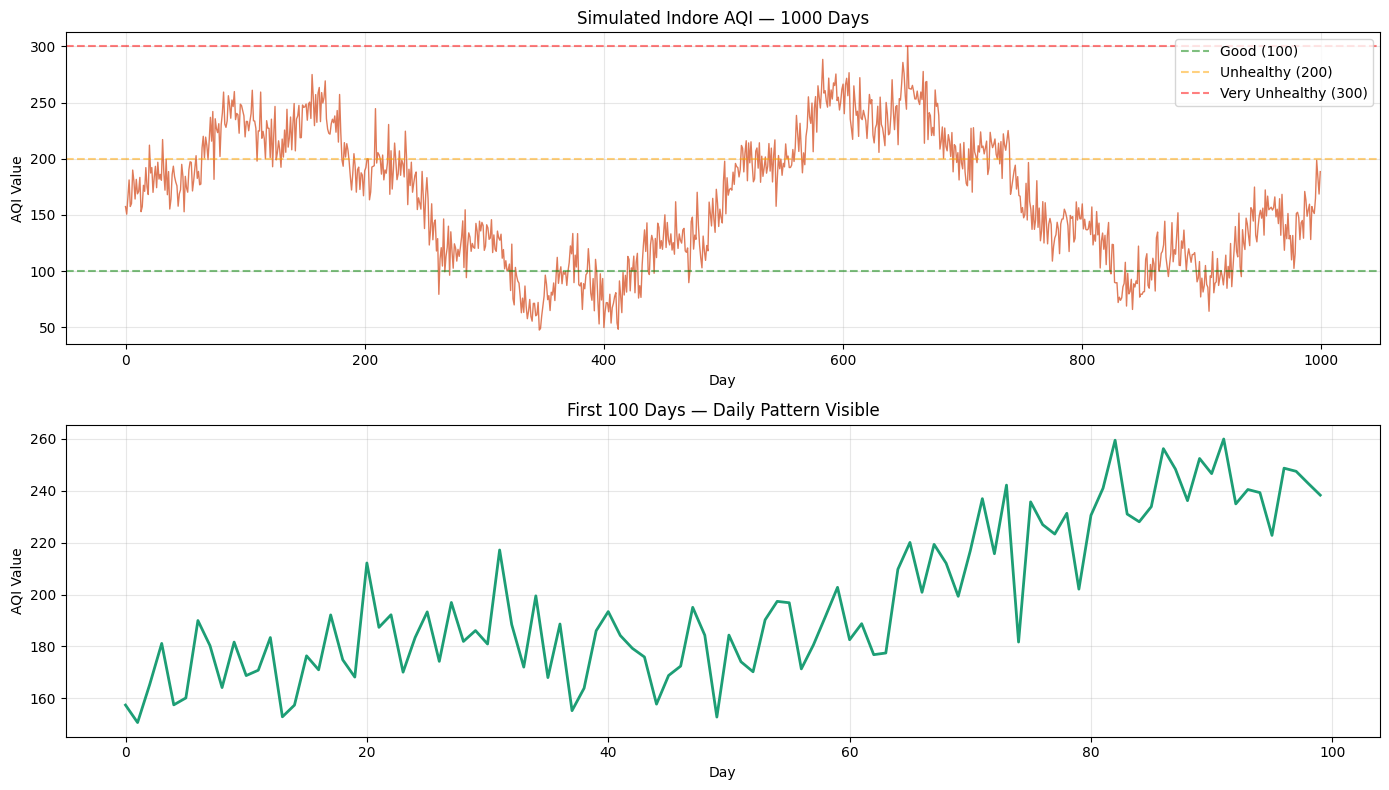

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(aqi_values, color='#D85A30',
             linewidth=1, alpha=0.8)
axes[0].set_title('Simulated Indore AQI — 1000 Days')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('AQI Value')
axes[0].axhline(100, color='green',
                linestyle='--', alpha=0.5,
                label='Good (100)')
axes[0].axhline(200, color='orange',
                linestyle='--', alpha=0.5,
                label='Unhealthy (200)')
axes[0].axhline(300, color='red',
                linestyle='--', alpha=0.5,
                label='Very Unhealthy (300)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(aqi_values[:100], color='#1D9E75',
             linewidth=2)
axes[1].set_title('First 100 Days — Daily Pattern Visible')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('AQI Value')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
scaler = MinMaxScaler(feature_range=(0, 1))
aqi_scaled = scaler.fit_transform(
    aqi_values.reshape(-1, 1)
).flatten()

print(f"After scaling: min={aqi_scaled.min():.3f}, "
      f"max={aqi_scaled.max():.3f}")

After scaling: min=0.000, max=1.000


In [22]:
SEQ_LEN = 30

def create_sequences(data, SEQ_LEN):
  x,y = [],[]
  for i in range(len(data) - SEQ_LEN):
    x.append(data[i : i + SEQ_LEN])
    y.append(data[i + SEQ_LEN])
  return np.array(x), np.array(y)

x, y = create_sequences(aqi_scaled, SEQ_LEN)

print(f"Total sequences: {len(x)}")
print(f"Each X shape: {x[0].shape}  "
      f"(30 days of AQI)")
print(f"Each y shape: scalar  "
      f"(1 day to predict)")
print(f"\nExample:")
print(f"X[0] = days 1-30:  "
      f"{x[0][:5].round(3)}...")
print(f"y[0] = day 31:     {y[0]:.3f}")



Total sequences: 970
Each X shape: (30,)  (30 days of AQI)
Each y shape: scalar  (1 day to predict)

Example:
X[0] = days 1-30:  [0.435 0.409 0.466 0.529 0.436]...
y[0] = day 31:     0.528


In [23]:
split = int(len(x)*0.8)
x_train = torch.FloatTensor(x[:split]).unsqueeze(-1)
x_test = torch.FloatTensor(x[split:]).unsqueeze(-1)
y_train = torch.FloatTensor(y[:split])
y_test = torch.FloatTensor(y[split:])

print(f"\nTraining sequences: {len(x_train)}")
print(f"Test sequences:     {len(x_test)}")
print(f"X_train shape: {x_train.shape}")
print("(sequences, timesteps, features)")
print("""
Why no shuffle for time series?
If you shuffle, Day 500 could be in training
and Day 499 in test. The model would have
seen the future during training — cheating.
Always keep time order intact.
""")


Training sequences: 776
Test sequences:     194
X_train shape: torch.Size([776, 30, 1])
(sequences, timesteps, features)

Why no shuffle for time series?
If you shuffle, Day 500 could be in training
and Day 499 in test. The model would have
seen the future during training — cheating.
Always keep time order intact.



In [24]:
class SimpleRNN(nn.Module):
  def __init__(self, input_size=1,
               hidden_size=32, num_layers=1):
    super(SimpleRNN, self).__init__()

    self.hidden_size = hidden_size
    self.num_layers = num_layers

    self.rnn = nn.RNN(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True
    )

    self.fc = nn.Linear(hidden_size, 1)

  def forward(self, x):
    h0 = torch.zeros(
        self.num_layers,
        x.size(0),
        self.hidden_size
    )

    out, hn = self.rnn(x, h0)

    last_out = out[:, -1, :]

    prediction = self.fc(last_out)
    return prediction.squeeze()

rnn_model = SimpleRNN()
print("Simple RNN created")
print(rnn_model)
total = sum(p.numel() for p in rnn_model.parameters())
print(f"Total parameters: {total:,}")

Simple RNN created
SimpleRNN(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Total parameters: 1,153


In [33]:
class LSTMPredictor(nn.Module):
  def __init__(self, input_size=1,
               hidden_size=64,
               num_layers=2,
               dropout=0.2):
    super(LSTMPredictor, self).__init__()

    self.hidden_size = hidden_size
    self.num_layers  = num_layers

    self.lstm = nn.LSTM(
        input_size  = input_size,
        hidden_size = hidden_size,
        num_layers  = num_layers,
        batch_first = True,
        dropout     = dropout  # between LSTM layers
    )

    self.fc = nn.Sequential(
        nn.Linear(hidden_size, 32),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(32, 1)
    )

  def forward(self, x):
    h0 = torch.zeros(self.num_layers,
                     x.size(0),
                     self.hidden_size)
    c0 = torch.zeros(self.num_layers,
                     x.size(0),
                     self.hidden_size)
    out, (hn, cn) = self.lstm(x, (h0, c0))

    last_out   = out[:, -1, :]
    prediction = self.fc(last_out)
    return prediction.squeeze()


lstm_model = LSTMPredictor()
print("LSTM model created")
print(lstm_model)
total_lstm = sum(p.numel()
                 for p in lstm_model.parameters())
print(f"Total parameters: {total_lstm:,}")

LSTM model created
LSTMPredictor(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total parameters: 52,545


In [34]:
def train_model(model, x_train, y_train,
                x_test, y_test,
                epochs=500, lr=0.001,
                model_name="Model"):

  criterion = nn.MSELoss()
  optimizer = optim.Adam(
      model.parameters(), lr=lr)

  train_losses = []
  test_losses = []

  for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    train_pred = model(x_train)
    train_loss = criterion(train_pred, y_train)
    train_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(), max_norm=1.0)

    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_pred = model(x_test)
        test_loss = criterion(test_pred, y_test)

    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())

    if epoch % 10 == 0:
        print(f"{model_name} | "
              f"Epoch {epoch:3d} | "
              f"Train Loss: {train_loss.item():.6f} | "
              f"Test Loss: {test_loss.item():.6f}")

  return train_losses, test_losses

print("\nTraining Simple RNN...")
rnn_train_losses, rnn_test_losses = train_model(
    rnn_model, x_train, y_train,
    x_test, y_test,
    epochs=50, model_name="RNN"
)

print("\nTraining LSTM...")
lstm_train_losses, lstm_test_losses = train_model(
    lstm_model, x_train, y_train,
    x_test, y_test,
    epochs=50, model_name="LSTM"
)


Training Simple RNN...
RNN | Epoch   0 | Train Loss: 0.027759 | Test Loss: 0.031699
RNN | Epoch  10 | Train Loss: 0.011207 | Test Loss: 0.010618
RNN | Epoch  20 | Train Loss: 0.006542 | Test Loss: 0.007617
RNN | Epoch  30 | Train Loss: 0.004705 | Test Loss: 0.004490
RNN | Epoch  40 | Train Loss: 0.004609 | Test Loss: 0.004243

Training LSTM...
LSTM | Epoch   0 | Train Loss: 0.584181 | Test Loss: 0.254874
LSTM | Epoch  10 | Train Loss: 0.418590 | Test Loss: 0.152021
LSTM | Epoch  20 | Train Loss: 0.124887 | Test Loss: 0.011417
LSTM | Epoch  30 | Train Loss: 0.076629 | Test Loss: 0.094934
LSTM | Epoch  40 | Train Loss: 0.065906 | Test Loss: 0.032057



--- CONCEPT 7: RNN vs LSTM Comparison ---


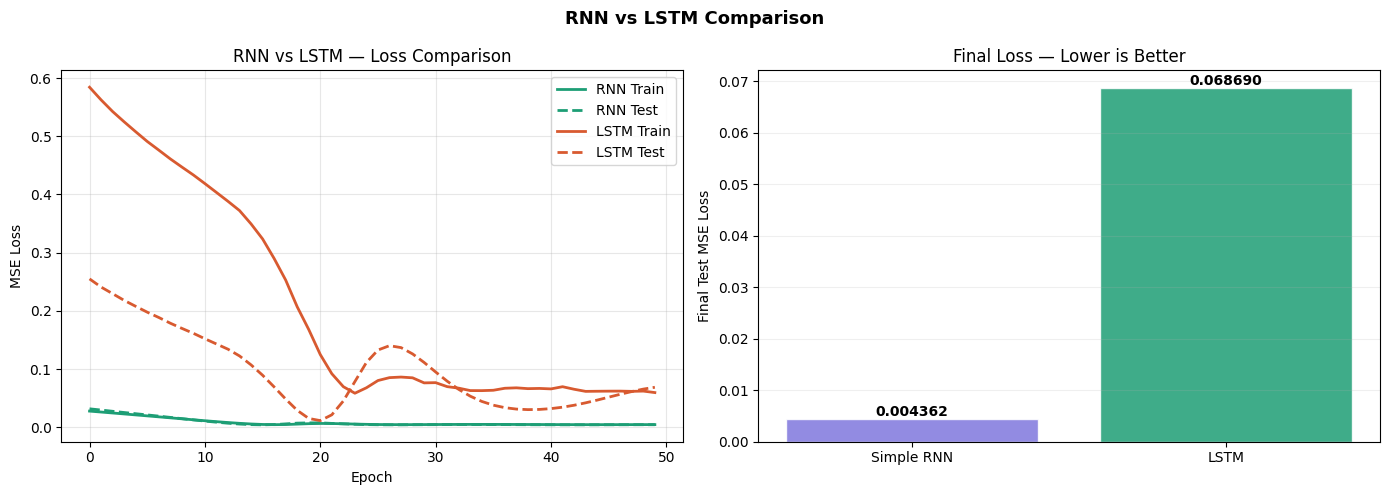

In [35]:
print("\n--- CONCEPT 7: RNN vs LSTM Comparison ---")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rnn_train_losses,
             color='#1D9E75', linewidth=2,
             label='RNN Train')
axes[0].plot(rnn_test_losses,
             color='#1D9E75', linewidth=2,
             linestyle='--', label='RNN Test')
axes[0].plot(lstm_train_losses,
             color='#D85A30', linewidth=2,
             label='LSTM Train')
axes[0].plot(lstm_test_losses,
             color='#D85A30', linewidth=2,
             linestyle='--', label='LSTM Test')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('RNN vs LSTM — Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Final losses
models_compared = ['Simple RNN', 'LSTM']
final_test      = [rnn_test_losses[-1],
                   lstm_test_losses[-1]]
colors_bar      = ['#7F77DD', '#1D9E75']

bars = axes[1].bar(models_compared, final_test,
                   color=colors_bar, alpha=0.85,
                   edgecolor='white')
for bar, val in zip(bars, final_test):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{val:.6f}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )
axes[1].set_ylabel('Final Test MSE Loss')
axes[1].set_title('Final Loss — Lower is Better')
axes[1].grid(True, alpha=0.2, axis='y')

plt.suptitle('RNN vs LSTM Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

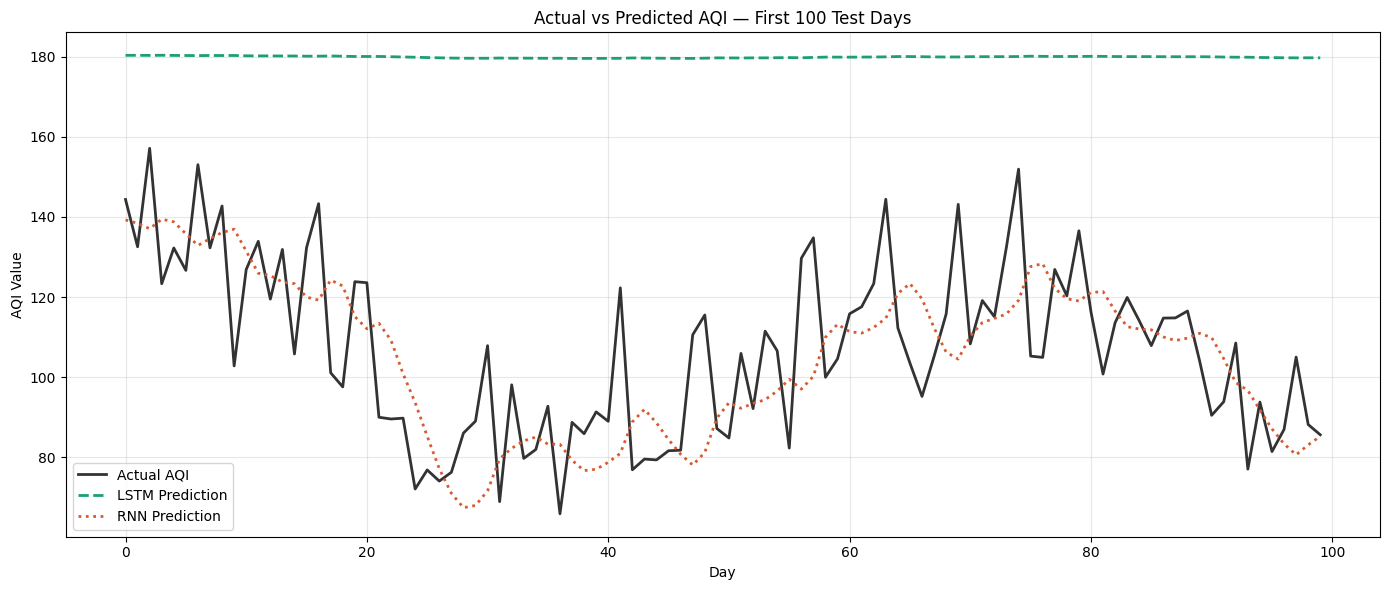

In [38]:

lstm_model.eval()
rnn_model.eval()

with torch.no_grad():
    lstm_preds = lstm_model(x_test).numpy()
    rnn_preds  = rnn_model(x_test).numpy()

# Inverse transform — convert back to real AQI values
lstm_preds_real = scaler.inverse_transform(
    lstm_preds.reshape(-1, 1)).flatten()
rnn_preds_real  = scaler.inverse_transform(
    rnn_preds.reshape(-1, 1)).flatten()
actual_real     = scaler.inverse_transform(
    y_test.numpy().reshape(-1, 1)).flatten()

# Plot predictions vs reality
plt.figure(figsize=(14, 6))
plt.plot(actual_real[:100],
         color='black', linewidth=2,
         label='Actual AQI', alpha=0.8)
plt.plot(lstm_preds_real[:100],
         color='#1D9E75', linewidth=2,
         label='LSTM Prediction', linestyle='--')
plt.plot(rnn_preds_real[:100],
         color='#D85A30', linewidth=2,
         label='RNN Prediction',  linestyle=':')
plt.xlabel('Day')
plt.ylabel('AQI Value')
plt.title('Actual vs Predicted AQI — First 100 Test Days')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
lstm_mae  = mean_absolute_error(
    actual_real, lstm_preds_real)
lstm_rmse = np.sqrt(mean_squared_error(
    actual_real, lstm_preds_real))

rnn_mae   = mean_absolute_error(
    actual_real, rnn_preds_real)
rnn_rmse  = np.sqrt(mean_squared_error(
    actual_real, rnn_preds_real))

print(f"{'Metric':20} {'RNN':>12} {'LSTM':>12}")
print("-" * 45)
print(f"{'MAE (AQI units)':20} "
      f"{rnn_mae:>12.2f} {lstm_mae:>12.2f}")
print(f"{'RMSE (AQI units)':20} "
      f"{rnn_rmse:>12.2f} {lstm_rmse:>12.2f}")

print(f"""
How to read these:
  MAE = on average predictions are off by X AQI units
  RMSE = similar but penalizes large errors more

If LSTM MAE = 12.5:
  On average the model's AQI prediction
  is within 12.5 units of the real value

  Real AQI: 180
  Predicted: 167-193 range

For health decisions that is useful —
you know if it will be good, moderate,
or unhealthy even if not exact.
""")

Metric                        RNN         LSTM
---------------------------------------------
MAE (AQI units)             13.10        60.37
RMSE (AQI units)            16.67        66.16

How to read these:
  MAE = on average predictions are off by X AQI units
  RMSE = similar but penalizes large errors more

If LSTM MAE = 12.5:
  On average the model's AQI prediction
  is within 12.5 units of the real value
  
  Real AQI: 180
  Predicted: 167-193 range
  
For health decisions that is useful —
you know if it will be good, moderate,
or unhealthy even if not exact.



In [44]:
def predict_future(model, last_sequence,
                   days_ahead=7):
    """
    Predict multiple days into the future.
    Uses its own predictions as input for next step.
    Called autoregressive prediction.
    """
    model.eval()
    predictions = []
    current_seq = last_sequence.copy()

    for day in range(days_ahead):
        seq_tensor = torch.FloatTensor(
            current_seq).unsqueeze(0).unsqueeze(-1)

        with torch.no_grad():
            next_pred = model(seq_tensor).item()

        predictions.append(next_pred)

        # Slide window forward
        # Remove oldest day, add new prediction
        current_seq = np.append(
            current_seq[1:], next_pred)

    # Convert back to real AQI
    predictions_real = scaler.inverse_transform(
        np.array(predictions).reshape(-1, 1)
    ).flatten()

    return predictions_real


# Use last 30 days as starting point
last_30_days = aqi_scaled[-SEQ_LEN:]
future_aqi   = predict_future(
    lstm_model, last_30_days, days_ahead=7)

print("7-Day AQI Forecast for Indore:")
print("-" * 35)

aqi_categories = {
    (0,   50):  ("Good"),
    (50,  100): ("Moderate"),
    (100, 150): ("Unhealthy (sens.)"),
    (150, 200): ("Unhealthy"),
    (200, 300): ("Very Unhealthy"),
    (300, 500): ("Hazardous"),
}

for i, aqi in enumerate(future_aqi):
    category = "Unknown"

    for (low, high), (cat) in aqi_categories.items():
        if low <= aqi < high:
            category = cat
            break
    print(f"Day {i+1}: AQI {aqi:6.1f}  "
          f"{category}")


7-Day AQI Forecast for Indore:
-----------------------------------
Day 1: AQI  180.7  Unhealthy
Day 2: AQI  180.7  Unhealthy
Day 3: AQI  180.8  Unhealthy
Day 4: AQI  180.8  Unhealthy
Day 5: AQI  180.8  Unhealthy
Day 6: AQI  180.8  Unhealthy
Day 7: AQI  180.8  Unhealthy


In [45]:
torch.save(lstm_model.state_dict(), 'lstm_aqi.pth')
torch.save(rnn_model.state_dict(),  'rnn_aqi.pth')
print("\nModels saved successfully")


Models saved successfully
